In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
### Make shortcut for numpy function
mvrnd = np.random.multivariate_normal
invert = np.linalg.inv
transpose = np.transpose

### Exercise 1 - Classification using least squares algorithm

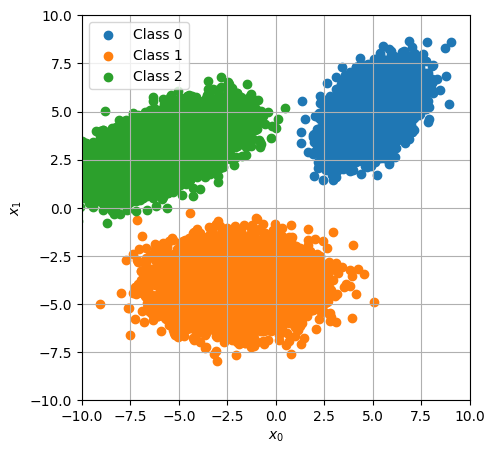

In [35]:
### Set the means and variances
N = int( 10e3 )
mu_0 = [5, 5]; sigma_0 = [[1, 0.5], [0.5, 1]]
mu_1 = [-2, -4]; sigma_1 = [[3, 0], [0, 1]]
mu_2 = [-6, 3]; sigma_2 = [[3, 1], [1, 1]]

### Generate samples from the 2 dimensional distributions
samples_0 = mvrnd( mu_0, sigma_0, N )
samples_1 = mvrnd( mu_1, sigma_1, N )
samples_2 = mvrnd( mu_2, sigma_2, N )

### Make a scatter plot of the samples
plt.figure(figsize=[5, 5,]); plt.grid();
lim = 10; plt.xlim([-lim, lim]); plt.ylim([-lim, lim])
plt.scatter( samples_0[:, 0], samples_0[:, 1], label='Class 0' )
plt.scatter( samples_1[:, 0], samples_1[:, 1], label='Class 1' )
plt.scatter( samples_2[:, 0], samples_2[:, 1], label='Class 2' )
plt.xlabel('$x_0$'); plt.ylabel('$x_1$'); plt.legend();

##### Part 1 - Generate the dataset

In [36]:
### Create labels
label0 = np.array( [1, 0] )                         # Create a single class-0-label
label1 = np.array( [0, 1] )                         # Create a single class-0-label
labels_0 = np.tile( label0, [N, 1] )                # Stack N class-0-labels into one matrix
labels_1 = np.tile( label1, [N, 1] )                # Stack N class-1-labels into one matrix

### Link samples and labels in one large dataset (sorted)
all_samples = np.concat( [samples_0, samples_1] )   # Create samples dataset (sorted)
all_labels = np.concat( [labels_0, labels_1] )      # Create labels dataset (sorted)

### Create shuffled dataset
shuffle_index = np.random.permutation( 2*N )        # Create random index for shuffling
X_data = all_samples[shuffle_index]                 # Use random index to shuffle samples
Y_data = all_labels[shuffle_index]                  # Use THE SAME random index to shuffle the labels

### Create train-test-split
N_train = int( 0.8 * len(all_samples) ); N_test = len(all_samples) - N_train    
X_train = X_data[:N_train]; Y_train = Y_data[:N_train]
X_test = X_data[N_train:]; Y_test = Y_data[N_train:]

### Add the bias column to the train and test samples
bias_train = np.ones( (X_train.shape[0], 1) )                       # Create bias column
bias_test = np.ones( (X_test.shape[0], 1) )                         # Create bias column
X_train_biased = np.concat( [bias_train, X_train], axis=1 )         # Stack traing data and bias column
X_test_biased = np.concat( [bias_test, X_test], axis=1 )            # Stack test data and bais column

##### Part 2 - Least squares classification (two classes)

In [37]:
### Perform one step weight calculation
X = X_train_biased
XT = transpose( X )
# Compute the least squares solution: W = (X^T X)^(-1) X^T Y
W_LS =  (np.linalg.inv(XT @ X))@(XT@Y_train) # 3 x 3                                                         # Apply the MPPI to calculate the weights in one step

print(X.shape)
print(W_LS.shape)



(16000, 3)
(3, 2)


In [38]:
### Make predictions on the test set
Y_pred_raw = (X_test_biased) @ W_LS                                 # Y_pred_raw contains the predictions as real numbers
Y_pred_ind = np.argmax( Y_pred_raw, axis=1 )                        # Y_pred_ind contains the index of the largest value of each sample
Y_pred = np.array( [label0, label1] )[Y_pred_ind]                   # Y_pred contains the labels that correspond to the predictions

### Count prediction errors
N_correct_predictions = np.all( Y_pred == Y_test, axis=1 ).sum()
N_errors = N_test - N_correct_predictions

print( 'Error rate = %.2f %%' % ( N_errors/N_test*100 ) )
print( 'Total number of errors: %d' % N_errors )

Error rate = 0.00 %
Total number of errors: 0


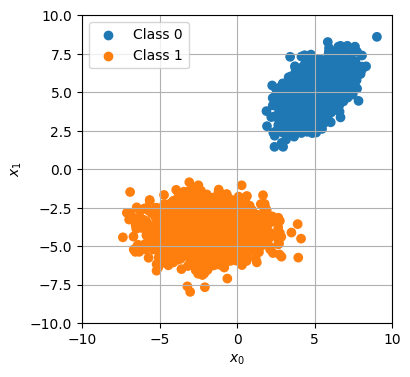

In [39]:
### Scatter the test samples colored according to their class.
# Figure setup
plt.figure(figsize=[4, 4,]); plt.grid();
lim = 10; plt.xlim([-lim, lim]); plt.ylim([-lim, lim])
plt.xlabel('$x_0$'); plt.ylabel('$x_1$');
base_colors = np.array(['tab:blue', 'tab:orange', 'tab:green' ])
plt.scatter([np.nan], [np.nan], label='Class 0')
plt.scatter([np.nan], [np.nan], label='Class 1')

# Scatter the X-samples with their predicted color
colors = base_colors[ Y_pred_ind ]
plt.scatter( X_test[:, 0], X_test[:, 1], color=colors)
plt.legend();

##### Part 3 - Least squares classification (three classes)

In [40]:
### Create labels
label0 = np.array( [1, 0, 0] )                         # Create a single class-0-label
label1 = np.array( [0, 1, 0] )                         # Create a single class-0-label
label2 = np.array( [0, 0, 1] )                      # Create a single class-2-label
labels_0 = np.tile( label0, [N, 1] )                # Stack N class-0-labels into one matrix
labels_1 = np.tile( label1, [N, 1] )                # Stack N class-1-labels into one matrix
labels_2 = np.tile( label2, [N, 1] )                # Stack N class-2-labels into one matrix

### Link samples and labels in one large dataset (sorted)
all_samples = np.concat( [samples_0, samples_1, samples_2] )   # Create samples dataset (sorted)
all_labels = np.concat( [labels_0, labels_1, labels_2] )      # Create labels dataset (sorted)

### Create shuffled dataset
shuffle_index = np.random.permutation( 3*N )        # Create random index for shuffling
X_data = all_samples[shuffle_index]                 # Use random index to shuffle samples
Y_data = all_labels[shuffle_index]                  # Use THE SAME random index to shuffle the labels

### Create train-test-split
N_train = int( 0.8 * len(all_samples) ); N_test = len(all_samples) - N_train    
X_train = X_data[:N_train]; Y_train = Y_data[:N_train]
X_test = X_data[N_train:]; Y_test = Y_data[N_train:]

### Add the bias column to the train and test samples
bias_train = np.ones( (X_train.shape[0], 1) )                       # Create bias column
bias_test = np.ones( (X_test.shape[0], 1) )                         # Create bias column
X_train_biased = np.concat( [bias_train, X_train], axis=1 )         # Stack traing data and bias column
X_test_biased = np.concat( [bias_test, X_test], axis=1 )            # Stack test data and bais column


In [41]:
### Perform one step weight calculation
X = X_train_biased
XT = transpose( X )
# Compute the least squares solution: W = (X^T X)^(-1) X^T Y
W_LS =  (np.linalg.inv(XT @ X))@(XT@Y_train) # 3 x 3                                                         # Apply the MPPI to calculate the weights in one step

print(X.shape)
print(W_LS.shape)
                                                            # Apply the MPPI to calculate the weights in one step

### Make predictions on the test set
Y_pred_raw = (X_test_biased) @ W_LS                                 # Y_pred_raw contains the predictions as real numbers
Y_pred_ind = np.argmax( Y_pred_raw, axis=1 )                        # Y_pred_ind contains the index of the largest value of each sample
Y_pred = np.array( [label0, label1, label2] )[Y_pred_ind]                   # Y_pred contains the labels that correspond to the predictions

### Count prediction errors
N_correct_predictions = np.all( Y_pred == Y_test, axis=1 ).sum()
N_errors = N_test - N_correct_predictions

print( 'Error rate = %.2f %%' % ( N_errors/N_test*100 ) )
print( 'Total number of errors: %d' % N_errors )

(24000, 3)
(3, 3)
Error rate = 0.05 %
Total number of errors: 3


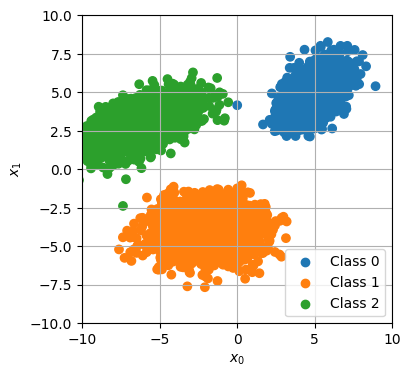

In [42]:
### Scatter the test samples colored according to their class.
# Figure setup
plt.figure(figsize=[4, 4,]); plt.grid();
lim = 10; plt.xlim([-lim, lim]); plt.ylim([-lim, lim])
plt.xlabel('$x_0$'); plt.ylabel('$x_1$');
base_colors = np.array(['tab:blue', 'tab:orange', 'tab:green' ])
plt.scatter([np.nan], [np.nan], label='Class 0')
plt.scatter([np.nan], [np.nan], label='Class 1')
plt.scatter([np.nan], [np.nan], label='Class 2')

# Scatter the X-samples with their predicted color
colors = base_colors[ Y_pred_ind ]
plt.scatter( X_test[:, 0], X_test[:, 1], color=colors)
plt.legend();

### Exercise 2 - Classification using Rosenblatt perceptron

C:\Users\mauri\AppData\Local\Temp\ipykernel_47548\1802776528.py:7: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_0 = mvrnd( mu_0, sigma_0, N )
C:\Users\mauri\AppData\Local\Temp\ipykernel_47548\1802776528.py:8: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_1 = mvrnd( mu_1, sigma_1, N )


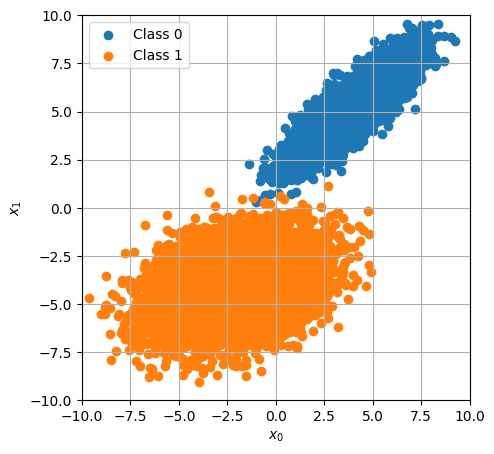

In [43]:
### Set the means and variances
N = int( 10e3 )
mu_0 = [4, 5.2]; sigma_0 = [[2.4, 2.1], [0.5, 0.8]]
mu_1 = [-2, -4]; sigma_1 = [[4, 1.2], [0, 1.6]]

### Generate samples from the 2 dimensional distributions
samples_0 = mvrnd( mu_0, sigma_0, N )
samples_1 = mvrnd( mu_1, sigma_1, N )

### Make a scatter plot of the samples
plt.figure(figsize=[5, 5,]); plt.grid();
lim = 10; plt.xlim([-lim, lim]); plt.ylim([-lim, lim])
plt.scatter( samples_0[:, 0], samples_0[:, 1], label='Class 0' )
plt.scatter( samples_1[:, 0], samples_1[:, 1], label='Class 1' )
plt.xlabel('$x_0$'); plt.ylabel('$x_1$'); plt.legend();

In [44]:
### Create labels
label0 = np.array( [ 1] )                           # Create a single class-0-label
label1 = np.array( [-1] )                           # Create a single class-0-label
labels_0 = np.tile( label0, [N, 1] )                # Stack N class-0-labels into one matrix
labels_1 = np.tile( label1, [N, 1] )                # Stack N class-1-labels into one matrix

### Link samples and labels in one large dataset (sorted)
all_samples = np.concat( [samples_0, samples_1] )   # Create samples dataset (sorted)
all_labels = np.concat( [labels_0, labels_1] )      # Create labels dataset (sorted)

### Create shuffled dataset
shuffle_index = np.random.permutation( 2*N )        # Create random index for shuffling
X_data = all_samples[shuffle_index]                 # Use random index to shuffle samples
Y_data = all_labels[shuffle_index]                  # Use THE SAME random index to shuffle the labels

### Create train-test-split
N_train = int( 0.8 * len(all_samples) ); N_test = len(all_samples) - N_train    
X_train = X_data[:N_train]; Y_train = Y_data[:N_train]
X_test = X_data[N_train:]; Y_test = Y_data[N_train:]

In [52]:
### Define perceptron
class perceptron():
    def __init__(self):                     # Create random initial weights
        self.weights = np.random.randn( 3 ) * 0.001

    def forward(self, x):
        v =  transpose(self.weights) @ x                              # Calculated the weighted sum
        return    np.sign(v)                         # Return the sign of the sum (±1)

In [53]:
### Train the weights
model = perceptron()
saved_weights = np.empty( (N_train, 3) )
eta = 1e-5

for i in range( N_train ):                                  # Loop through all the training samples
    X_biased = np.concat( [np.ones(1), X_train[i]] )        # Add bias to the input
    Y_pred = model.forward( X_biased )                      # Get prediction from the model
    delta_w =  eta * (Y_train[i] - Y_pred) * X_biased                                           # Calculate the weight update
    model.weights = model.weights + delta_w                 # Update the model's weights
    saved_weights[i] = np.array( np.copy( model.weights ) ) # Store the weights for later inspection

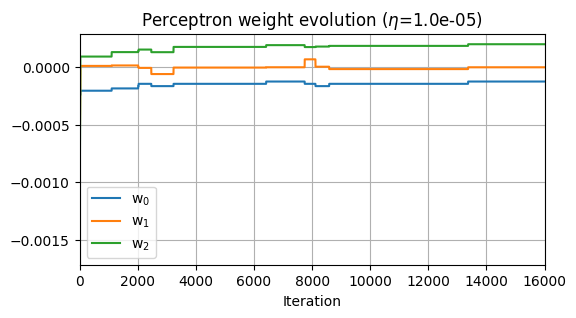

In [54]:
plt.figure( figsize=[6, 3] ); plt.grid()
plt.title( r'Perceptron weight evolution ($\eta$=%.1e)' % eta )
plt.plot( saved_weights[:, 0], label='w$_0$' )
plt.plot( saved_weights[:, 1], label='w$_1$' )
plt.plot( saved_weights[:, 2], label='w$_2$' )
plt.legend(); plt.xlim([0, N_train]);
plt.xlabel( 'Iteration' );

In [57]:
### Use the trained model to make predictions on the test data
Y_pred = np.empty( Y_test.shape )
for i in range( N_test ):
    X_biased = np.concat( [np.ones(1), X_test[i]] )
    Y_pred[i] = model.forward( X_biased )

### Count prediction errors
N_correct_predictions =  np.all( Y_pred == Y_test, axis=1 ).sum()    
N_errors = N_test - N_correct_predictions

print( 'Error rate = %.2f %%' % ( N_errors/N_test*100 ) )
print( 'Total number of errors: %d' % N_errors )

Error rate = 0.00 %
Total number of errors: 0


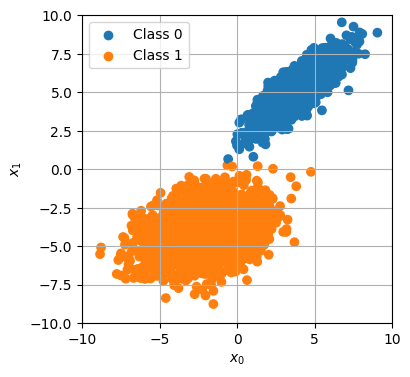

In [58]:
### Scatter the test samples colored according to their class.
# Figure setup
plt.figure(figsize=[4, 4,]); plt.grid();
lim = 10; plt.xlim([-lim, lim]); plt.ylim([-lim, lim])
plt.xlabel('$x_0$'); plt.ylabel('$x_1$');
base_colors = np.array(['tab:blue', 'tab:orange' ])
plt.scatter([np.nan], [np.nan], label='Class 0')
plt.scatter([np.nan], [np.nan], label='Class 1')

# Scatter the X-samples with their predicted color
Y_pred_ind = np.int8( ( -Y_pred + 1 ) // 2 )[:, 0]          # Map {1, -1} to  [0, 1]
colors = base_colors[ Y_pred_ind ]                  
plt.scatter( X_test[:, 0], X_test[:, 1], color=colors)
plt.legend();

### Exercise 3 - Classification using Logistic Perceptron

C:\Users\mauri\AppData\Local\Temp\ipykernel_47548\1802776528.py:7: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_0 = mvrnd( mu_0, sigma_0, N )
C:\Users\mauri\AppData\Local\Temp\ipykernel_47548\1802776528.py:8: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples_1 = mvrnd( mu_1, sigma_1, N )


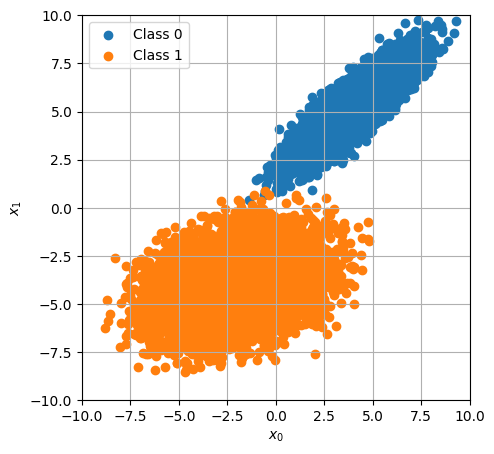

In [59]:
### Set the means and variances
N = int( 10e3 )
mu_0 = [4, 5.2]; sigma_0 = [[2.4, 2.1], [0.5, 0.8]]
mu_1 = [-2, -4]; sigma_1 = [[4, 1.2], [0, 1.6]]

### Generate samples from the 2 dimensional distributions
samples_0 = mvrnd( mu_0, sigma_0, N )
samples_1 = mvrnd( mu_1, sigma_1, N )

### Make a scatter plot of the samples
plt.figure(figsize=[5, 5,]); plt.grid();
lim = 10; plt.xlim([-lim, lim]); plt.ylim([-lim, lim])
plt.scatter( samples_0[:, 0], samples_0[:, 1], label='Class 0' )
plt.scatter( samples_1[:, 0], samples_1[:, 1], label='Class 1' )
plt.xlabel('$x_0$'); plt.ylabel('$x_1$'); plt.legend();

In [60]:
### Create labels
label0 = np.array( [ 0 ] )                          # Create a single class-0-label
label1 = np.array( [ 1 ] )                          # Create a single class-0-label
labels_0 = np.tile( label0, [N, 1] )                # Stack N class-0-labels into one matrix
labels_1 = np.tile( label1, [N, 1] )                # Stack N class-1-labels into one matrix

### Link samples and labels in one large dataset (sorted)
all_samples = np.concat( [samples_0, samples_1] )   # Create samples dataset (sorted)
all_labels = np.concat( [labels_0, labels_1] )      # Create labels dataset (sorted)

### Create shuffled dataset
shuffle_index = np.random.permutation( 2*N )        # Create random index for shuffling
X_data = all_samples[shuffle_index]                 # Use random index to shuffle samples
Y_data = all_labels[shuffle_index]                  # Use THE SAME random index to shuffle the labels

### Create train-test-split
N_train = int( 0.8 * len(all_samples) ); N_test = len(all_samples) - N_train    
X_train = X_data[:N_train]; Y_train = Y_data[:N_train]
X_test = X_data[N_train:]; Y_test = Y_data[N_train:]

In [ ]:
### Define sigmoid function
def sigmoid( x ):
    return 

### Define logistic perceptron
class logistic_perceptron():
    def __init__(self):                     # Create random initial weights
        

    def forward(self, x):
        
          

In [ ]:
### Train the weights
N_iterations = 10
model = logistic_perceptron()
saved_weights = np.empty( (N_train, 3) )
eta = 1e-4


for i in range( N_train ):
    X_biased =
    Y_pred = 
    delta_w = 
    model.weights = 

    saved_weights[i] = np.array( np.copy( model.weights ) )

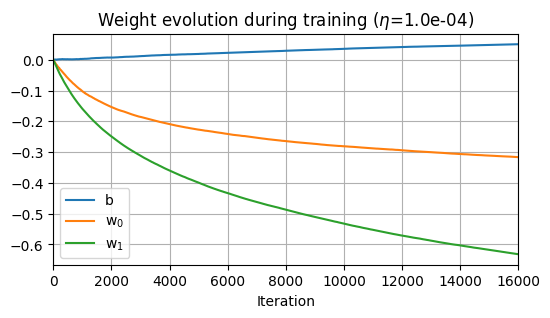

In [68]:
plt.figure( figsize=[6, 3] ); plt.grid()
plt.title( r'Weight evolution during training ($\eta$=%.1e)' % eta )
plt.plot( saved_weights[:, 0], label='b' )
plt.plot( saved_weights[:, 1], label='w$_0$' )
plt.plot( saved_weights[:, 2], label='w$_1$' )
plt.legend(); plt.xlim([0, N_train]);
plt.xlabel('Iteration');

In [75]:
### Use the trained model to make predictions on the test data
Y_pred = np.empty( Y_test.shape )
for i in range( N_test ):
    X_biased = np.concat( [np.ones(1), X_test[i]] )
    prediction = model.forward( X_biased )
    Y_pred[i] = np.round( prediction )

### Count prediction errors
N_correct_predictions = np.all( Y_pred == Y_test, axis=1 ).sum()
N_errors = N_test - N_correct_predictions

print( 'Error rate = %.2f %%' % ( N_errors/N_test*100 ) )
print( 'Total number of errors: %d' % N_errors )

Error rate = 0.27 %
Total number of errors: 11


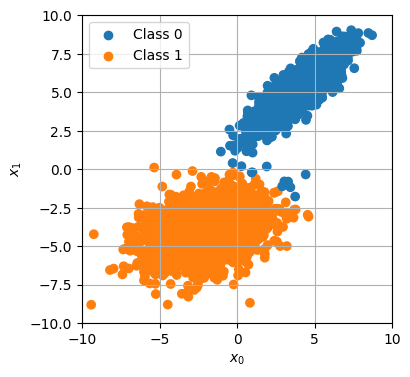

In [87]:
### Scatter the test samples colored according to their class.
# Figure setup
plt.figure(figsize=[4, 4,]); plt.grid();
lim = 10; plt.xlim([-lim, lim]); plt.ylim([-lim, lim])
plt.xlabel('$x_0$'); plt.ylabel('$x_1$');
base_colors = np.array(['tab:blue', 'tab:orange' ])
plt.scatter([np.nan], [np.nan], label='Class 0')
plt.scatter([np.nan], [np.nan], label='Class 1')

# Scatter the X-samples with their predicted color
colors = base_colors[ np.int8( Y_pred ) ][:, 0]
plt.scatter( X_test[:, 0], X_test[:, 1], color=colors)
plt.legend();